<a href="https://colab.research.google.com/github/bmanibharathibe/trendpulse-manibharathi/blob/main/task4_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import requests
import pandas as pd

url = "https://api.github.com/search/repositories?q=stars:>10000&sort=stars"

response = requests.get(url)
data = response.json()

repos = []

for repo in data['items']:
    repos.append({
        "name": repo["name"],
        "owner": repo["owner"]["login"],
        "stars": repo["stargazers_count"],
        "forks": repo["forks_count"],
        "language": repo["language"]
    })

df = pd.DataFrame(repos)

df.to_csv("trending_repos_raw.csv", index=False)

print("CSV file created")

CSV file created


In [8]:
import os
os.listdir()

['.config', 'trending_repos_raw.csv', 'sample_data']

In [9]:
import pandas as pd
import os

file = "trending_repos_raw.csv"

if os.path.exists(file):
    df = pd.read_csv(file)

    df["language"] = df["language"].fillna("Unknown")
    df = df.drop_duplicates()
    df = df.sort_values(by="stars", ascending=False)

    df.to_csv("trending_repos_cleaned.csv", index=False)

    print("Processing complete")
    print(df.head())

else:
    print("Error: CSV file not found. Please run task1_data_collection.py first.")

Processing complete
                     name            owner   stars  forks    language
0        build-your-own-x  codecrafters-io  487429  45863    Markdown
1                 awesome     sindresorhus  453179  34041     Unknown
2            freeCodeCamp     freeCodeCamp  442215  44183  TypeScript
3             public-apis      public-apis  420196  45721      Python
4  free-programming-books  EbookFoundation  385191  66092      Python


In [10]:
import pandas as pd
import os

file = "trending_repos_cleaned.csv"

if os.path.exists(file):

    df = pd.read_csv(file)

    # Top 5 repositories by stars
    top_repos = df.sort_values(by="stars", ascending=False).head(5)

    # Count repositories by language
    language_counts = df["language"].value_counts()

    print("Top 5 Trending Repositories")
    print(top_repos[["name", "stars"]])

    print("\nRepository Count by Language")
    print(language_counts)

else:
    print("Error: cleaned CSV file not found. Please run task2_data_processing.py first.")

Top 5 Trending Repositories
                     name   stars
0        build-your-own-x  487429
1                 awesome  453179
2            freeCodeCamp  442215
3             public-apis  420196
4  free-programming-books  385191

Repository Count by Language
language
Unknown             8
TypeScript          6
Python              6
JavaScript          2
Markdown            1
C                   1
HTML                1
C++                 1
Shell               1
Jupyter Notebook    1
Rust                1
Dart                1
Name: count, dtype: int64


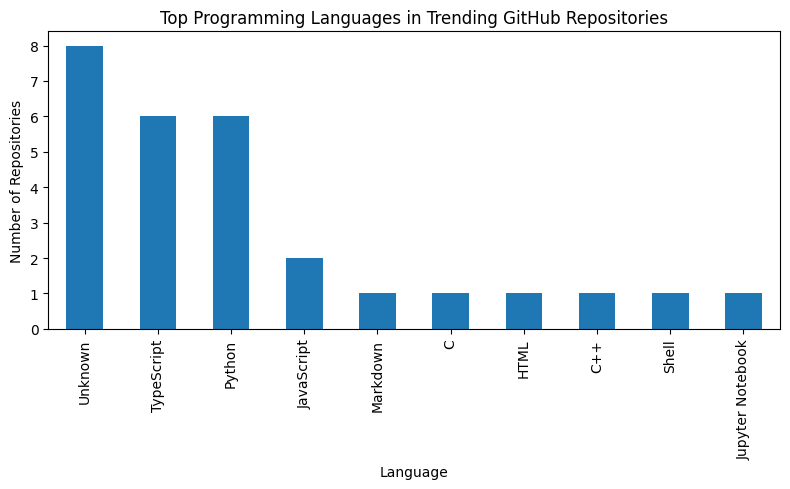

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import os

file = "trending_repos_cleaned.csv"

if os.path.exists(file):

    df = pd.read_csv(file)

    # Count languages
    language_counts = df["language"].value_counts().head(10)

    # Plot bar chart
    plt.figure(figsize=(8,5))
    language_counts.plot(kind="bar")

    plt.title("Top Programming Languages in Trending GitHub Repositories")
    plt.xlabel("Language")
    plt.ylabel("Number of Repositories")

    plt.tight_layout()
    plt.show()

else:
    print("Error: cleaned CSV file not found. Please run task2_data_processing.py first.")